In [2]:
# 必要package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bilby
from bilby.gw.conversion import luminosity_distance_to_redshift
from bilby.gw.conversion import redshift_to_luminosity_distance
from astropy import units
from astropy import constants as const
from astropy.cosmology import Planck18 as cosmo
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Cosmo.lens_cosmo import LensCosmo
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from gwpy.time import Time as GWTime
import os
import tempfile
import shutil

# 在系统临时文件夹中创建临时文件
tmp_dir = tempfile.gettempdir()

# 宇宙学模型
bilby.gw.cosmology.DEFAULT_COSMOLOGY=cosmo
bilby.gw.cosmology.COSMOLOGY = [cosmo, cosmo.name]
bilby.gw.cosmology.get_cosmology()  # 查看默认宇宙学模型

FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

# 0. 参数设置
## 所有可以更改的参数均在这个单元
### 0.0 随机种子

In [3]:
# random seed 

n=613 #lensed

### 0.1 源参数
### 设置单元格1.1中波源参数的采样范围
n_samples: 总样本个数

z：波源红移 (建议范围 0 < z_s <= 2)

d_L：波源光度距离

m：源参考系下黑洞质量

time：波形到达时间

其余参数使用默认即可


In [4]:
# 总样本个数
n_samples=5

# 源红移范围 
z_min=0.01
z_max=2
d_L_min = redshift_to_luminosity_distance(z_min)
d_L_max = redshift_to_luminosity_distance(z_max)
print("d_L_min:",d_L_min)
print("d_L_max:",d_L_max)


# 源质量范围
m_min=10
m_max=70

# 波形到达地心时间范围，可自定义时间段
time_start = GWTime('2015-09-14 09:50:45.39', scale='utc').gps
time_end=GWTime('2025-12-10 17:18:45.39', scale='utc').gps

d_L_min: 44.64710613238465
d_L_max: 15924.566651659155


### 0.2 透镜参数
### 从n_samples个波源中，随机挑选n_lens个，作为被透镜化的GW波源
### 如果不需要生成透镜化数据，设为0即可。如果需要纯透镜化数据，设为n_samples即可
n_lens: 透镜化样本个数( <=n_samples)

In [5]:
#透镜化样本个数（小于等于 n_samples）
n_lens=5

### 0.3 GW波形参数
### 设置波形的采样频率以及数据时长
sampling_frequency: 采样频率(建议 >=4096Hz)

duration: 数据时长(建议 >16s,太短可能无法容纳GW波形.如果实在需要更短的data,可以增大minimum_frequency)

minimum_frequency: 引力波波形的起始频率(建议20Hz-40HZ)

In [6]:
sampling_frequency=4096  # f_s >= 2*f_max   #
duration=24  # len(strain_data) = f_s*duration
minimum_frequency=20.0

# 1. Source generation
## 1.1 All GW sources
### 使用bilby内置先验分布对GW参数进行采样，产生n_samples个源
### 运行此单元格，保存所有波源参数至文件 source_samples.csv

dict_keys(['luminosity_distance', 'mass_1_source', 'mass_2_source', 'a_1', 'a_2', 'tilt_1', 'tilt_2', 'phi_12', 'phi_jl', 'ra', 'dec', 'theta_jn', 'psi', 'phase', 'geocent_time'])


,luminosity_distance,mass_1_source,mass_2_source,a_1,a_2,tilt_1,tilt_2,phi_12,phi_jl,ra,dec,theta_jn,psi,phase,geocent_time
0,13960.814998,67.587322,10.573490,0.751218,0.114108,1.936535,1.583258,2.289167,6.265101,4.171824,-0.471871,0.220991,2.811789,2.268665,1.437004e+09
1,13529.983406,65.512602,35.478969,0.450130,0.679246,2.511318,1.881311,2.032361,2.045031,5.080900,0.288071,0.966274,2.917448,4.755806,1.434314e+09
2,13064.099258,48.182130,18.137811,0.759433,0.903215,0.808883,0.341882,5.605499,1.509941,5.148996,0.800286,1.715070,1.310292,3.124091,1.340309e+09
3,9574.363471,62.969955,22.446742,0.453539,0.832845,2.935396,2.549100,2.762312,0.521837,1.208625,-0.245977,0.622661,1.733657,2.363948,1.407378e+09
4,12031.101047,12.244818,46.932833,0.742874,0.866641,1.427345,2.623734,5.295813,5.298956,1.268355,-0.283495,0.795592,2.118492,4.608975,1.140982e+09


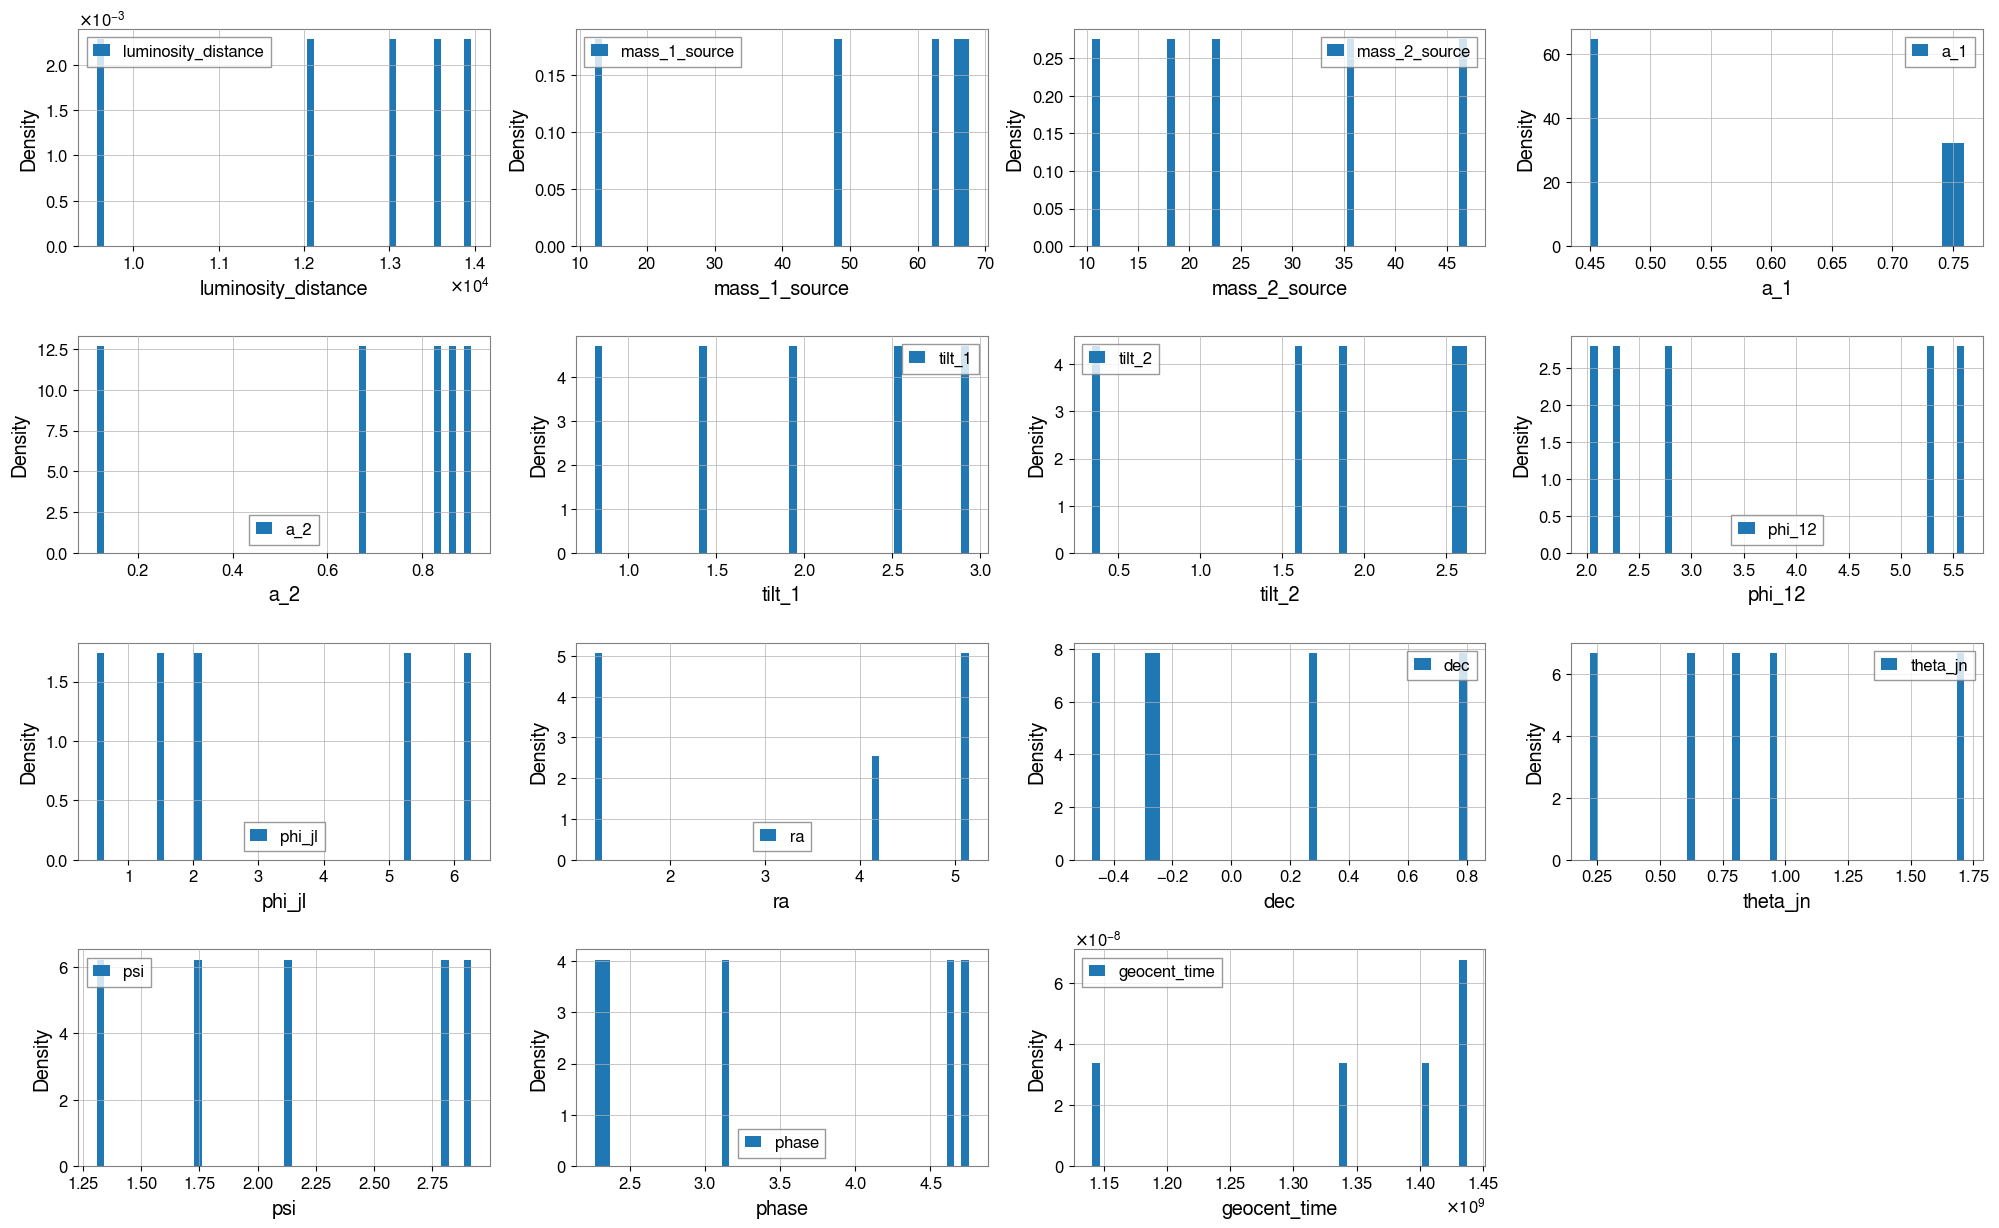

In [7]:
bilby.core.utils.random.seed(n)


# sampling from priors
def prior_GW():
    priors = bilby.core.prior.PriorDict()
    priors['luminosity_distance']=bilby.gw.prior.UniformComovingVolume(
        name="luminosity_distance", minimum=d_L_min, maximum=d_L_max, latex_label="r'$d_L$ (Mpc)'")
    priors['mass_1_source']= bilby.core.prior.Uniform(m_min, m_max, 'mass_1_source')
    priors['mass_2_source']= bilby.core.prior.Uniform(m_min, m_max, 'mass_2_source')
    priors['a_1']= bilby.core.prior.Uniform(0, 0.99, 'a_1')
    priors['a_2']= bilby.core.prior.Uniform(0, 0.99, 'a_2')
    priors['tilt_1']= bilby.core.prior.Sine(name='tilt_1')
    priors['tilt_2']= bilby.core.prior.Sine(name='tilt_2')
    priors['phi_12']= bilby.core.prior.Uniform(0, 2 * np.pi, 'phi_12', boundary='periodic')
    priors['phi_jl']= bilby.core.prior.Uniform(0, 2 * np.pi, 'phi_jl', boundary='periodic')
    priors['ra']= bilby.core.prior.Uniform(0, 2 * np.pi, 'ra', boundary='periodic')
    priors['dec']= bilby.core.prior.Cosine(name='dec')
    priors['theta_jn']= bilby.core.prior.Sine(name='theta_jn')
    priors['psi']= bilby.core.prior.Uniform(0, np.pi, 'psi', boundary='periodic')
    priors['phase']= bilby.core.prior.Uniform(0, 2 * np.pi, 'phase', boundary='periodic')
    priors['geocent_time']= bilby.core.prior.Uniform(time_start, time_end, 'geocent_time')

    return priors

priors = prior_GW()
samples = priors.sample(n_samples)
print(samples.keys())

fig, axes = plt.subplots(5, 4, figsize=(20, 15))
axes = axes.flatten()
for i, key in enumerate(samples.keys()):
    ax = axes[i]
    ax.hist(samples[key], bins=50, density=True, label=key)
    ax.set_xlabel(key)
    ax.set_ylabel('Density')
    ax.legend()
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
# plt.savefig('source_samples.pdf')


# 保存数据
source_params = pd.DataFrame(samples)
source_params.to_csv('source_samples.csv', index=False)
source_params

## 1.2 Lensed GW index
### 从n_samples个波源中，随机挑选n_lens个，作为被透镜化的GW波源
### 运行此单元格，得到透镜化波源(第一个像)在source_samples中对应的index及参数，并保存index至文件 lensed_index.csv

In [8]:
source_params=pd.read_csv('source_samples.csv')

np.random.seed(n)
idx = np.random.choice(n_samples, n_lens, replace=False)
idx = np.sort(idx)

print(idx)
idx={'lensed_index': idx}
lensed_index=pd.DataFrame(idx)
lensed_index.to_csv('lensed_index.csv', index=False)
lensed_index

lensed_source_1 = source_params.iloc[lensed_index['lensed_index']]
lensed_source_1

[0 1 2 3 4]


,luminosity_distance,mass_1_source,mass_2_source,a_1,a_2,tilt_1,tilt_2,phi_12,phi_jl,ra,dec,theta_jn,psi,phase,geocent_time
0,13960.814998,67.587322,10.573490,0.751218,0.114108,1.936535,1.583258,2.289167,6.265101,4.171824,-0.471871,0.220991,2.811789,2.268665,1.437004e+09
1,13529.983406,65.512602,35.478969,0.450130,0.679246,2.511318,1.881311,2.032361,2.045031,5.080900,0.288071,0.966274,2.917448,4.755806,1.434314e+09
2,13064.099258,48.182130,18.137811,0.759433,0.903215,0.808883,0.341882,5.605499,1.509941,5.148996,0.800286,1.715070,1.310292,3.124091,1.340309e+09
3,9574.363471,62.969955,22.446742,0.453539,0.832845,2.935396,2.549100,2.762312,0.521837,1.208625,-0.245977,0.622661,1.733657,2.363948,1.407378e+09
4,12031.101047,12.244818,46.932833,0.742874,0.866641,1.427345,2.623734,5.295813,5.298956,1.268355,-0.283495,0.795592,2.118492,4.608975,1.140982e+09


## 1.3 Lens modeling
### 根据PM模型，计算透镜放大率和时间延迟

### 透镜参数

#### 设定量：

z_l: 透镜红移 

z_s: 源红移

m_l: 透镜星系的质量(太阳质量) 

y: 无量纲源位置

#### 中间量：

theta_E: 爱因斯坦角(arcsec)

phi: 源在源平面的方位角(rad)

beta_x, beta_y: 源的角位置(arcsec) 

#### 计算量：

mu_1, mu_2: 透镜放大率(第一个像和第二个像)

t_d: 两像之间延迟(s)

### 运行此单元格，将透镜参数（设定+中间量）保存至文件 lens_params.csv，透镜放大率与相对时间延迟保存至文件 lens.csv

In [9]:
np.random.seed(n)
rng = np.random.default_rng(n)
ms=const.M_sun.to(units.kg).value  # 太阳质量(kg)
G=const.G.value  # gravitational constant (m3 kg-1 s-2)
c=const.c.value  # speed of light (m/s)


tmp_params = os.path.join(tmp_dir, "lens_params.tmp.csv")
tmp_lens   = os.path.join(tmp_dir, "lens.tmp.csv")

for p in [tmp_params, tmp_lens]:
    if os.path.exists(p):
        os.remove(p)

pd.DataFrame(columns=["z_l", 
                      "z_s", 
                      "m_l",
                      "theta_E(arcsec)", 
                      "y",
                      "beta_x", 
                      "beta_y"]).to_csv(tmp_params, index=False)

pd.DataFrame(columns=["mu_0",
                      "mu_1", 
                      "t_d"]).to_csv(tmp_lens, index=False)


for i in range(n_lens):
    # 源红移
    dL = lensed_source_1.iloc[i]['luminosity_distance']
    z_s = luminosity_distance_to_redshift(dL)

    # 透镜红移（这里取源红移的一半）
    z_l = z_s / 2

    # 透镜质量(太阳质量)
    m_l = np.random.uniform(1e8, 1e10)*ms  # 对应SMBH，且保证时延在s量级，可区分两像

    lens_cosmo = LensCosmo(z_lens=z_l, z_source=z_s, cosmo=cosmo)
    Dls=(lens_cosmo.dds*units.Mpc).to(units.m).value
    Dl=(lens_cosmo.dd*units.Mpc).to(units.m).value
    Ds=(lens_cosmo.ds*units.Mpc).to(units.m).value

    # Einstein radius (arcsec)
    theta_E = np.sqrt((4*G*m_l/c**2)*(Dls/(Dl*Ds)))*(180*3600/np.pi)
    
    print('z_s =', z_s)
    print('z_l =', z_l)
    print('m_l =', m_l)
    print('theta_E =', theta_E)


    y = np.random.uniform(0.01, 0.3)   # 不大于0.3，保证第二个像放大率 > 1
    phi= np.random.uniform(0, 2*np.pi)
    beta_x= y*theta_E* np.cos(phi)
    beta_y= y*theta_E* np.sin(phi)

    print('y =', y)
    print('beta_x =', beta_x)
    print('beta_y =', beta_y)

    mu_plus=1/2+(y**2+2)/(2*y*np.sqrt(y**2+4))
    mu_minus=1/2-(y**2+2)/(2*y*np.sqrt(y**2+4))
    
    t_d=4*G*m_l*(1+z_l)*c**(-3)*(0.5*y*np.sqrt(y**2+4)+np.log((np.sqrt(y**2+4)+y)/(np.sqrt(y**2+4)-y)))
    print(mu_plus, mu_minus)
    print(t_d,'s','=',t_d/(24*3600),'days')
    print()

    row_0 = pd.DataFrame([{
        "z_l": z_l,
        "z_s": z_s,
        "m_l": m_l/ms,
        "theta_E(arcsec)": theta_E,
        "y": y,
        "beta_x": beta_x,
        "beta_y": beta_y}])
    
    row_1 = pd.DataFrame([{
        "mu_0": mu_plus,
        "mu_1": mu_minus,
        "t_d": t_d}])

    row_0.to_csv(tmp_params, mode="a", header=False, index=False)
    row_1.to_csv(tmp_lens,   mode="a", header=False, index=False)


final_params = "lens_params.csv"
final_lens = "lens.csv"

for p in [final_params, final_lens]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(tmp_params, final_params)
shutil.move(tmp_lens, final_lens)

z_s = 1.7958647840894573
z_l = 0.8979323920447286
m_l = 1.5710736340635977e+40
theta_E = 0.12044990734624801
y = 0.252990732936276
beta_x = 0.030014770864147017
beta_y = 0.005263041472178231
2.523479976510228 -1.5234799765102278
149888.87211407372 s = 1.734824908727705 days

z_s = 1.750492947012186
z_l = 0.875246473506093
m_l = 1.7212821707867845e+40
theta_E = 0.12701598766930144
y = 0.15365860882812835
beta_x = -0.019349542506062547
beta_y = -0.0025519396188940706
3.782707144740775 -2.782707144740775
98384.70643135457 s = 1.1387118799925298 days

z_s = 1.7011672075949797
z_l = 0.8505836037974899
m_l = 1.8240417848079853e+40
theta_E = 0.13185413254415218
y = 0.294302293389585
beta_x = -0.03714029901499284
beta_y = -0.011243850106754256
2.2536246469463634 -1.2536246469463632
197574.1925796354 s = 2.2867383400420764 days

z_s = 1.321283681112803
z_l = 0.6606418405564015
m_l = 1.8944151566297913e+40
theta_E = 0.14533985445299188
y = 0.1068433026059047
beta_x = -0.010832232986646676
beta_y

'lens.csv'

## 1.4 All lensed GW source
### 透镜产生双像，所以n_lens个透镜会产生 2 * n_lens个像，相当于有 2 * n_lens组源的参数和data
### 运行此单元格，产生第二个像的源参数（伪源参数，t_2=t_1+t_d，其余参数保持一致）,保存所有透镜化GW源的参数至文件 lensed_source_samples.csv

In [10]:
lens=pd.read_csv('lens.csv')

t_d=[]
for i in range(len(lens)):
    t_d.append((lens['t_d'][i]))
print(t_d)

original_times = lensed_source_1['geocent_time'].values
# print(original_times)

geocent_time_2 = original_times + t_d
# print(geocent_time_2)

lensed_source_2 = lensed_source_1.copy()
lensed_source_2['geocent_time'] = geocent_time_2

lensed_source_params = pd.concat([lensed_source_1, lensed_source_2], axis=0, ignore_index=False)
lensed_source_params.to_csv('lensed_source_samples.csv', index=False)

lensed_source_params

[149888.87211407372, 98384.70643135456, 197574.1925796354, 66640.53488598639, 52597.45624658476]


,luminosity_distance,mass_1_source,mass_2_source,a_1,a_2,tilt_1,tilt_2,phi_12,phi_jl,ra,dec,theta_jn,psi,phase,geocent_time
0,13960.814998,67.587322,10.573490,0.751218,0.114108,1.936535,1.583258,2.289167,6.265101,4.171824,-0.471871,0.220991,2.811789,2.268665,1.437004e+09
1,13529.983406,65.512602,35.478969,0.450130,0.679246,2.511318,1.881311,2.032361,2.045031,5.080900,0.288071,0.966274,2.917448,4.755806,1.434314e+09
2,13064.099258,48.182130,18.137811,0.759433,0.903215,0.808883,0.341882,5.605499,1.509941,5.148996,0.800286,1.715070,1.310292,3.124091,1.340309e+09
3,9574.363471,62.969955,22.446742,0.453539,0.832845,2.935396,2.549100,2.762312,0.521837,1.208625,-0.245977,0.622661,1.733657,2.363948,1.407378e+09
4,12031.101047,12.244818,46.932833,0.742874,0.866641,1.427345,2.623734,5.295813,5.298956,1.268355,-0.283495,0.795592,2.118492,4.608975,1.140982e+09
0,13960.814998,67.587322,10.573490,0.751218,0.114108,1.936535,1.583258,2.289167,6.265101,4.171824,-0.471871,0.220991,2.811789,2.268665,1.437154e+09
1,13529.983406,65.512602,35.478969,0.450130,0.679246,2.511318,1.881311,2.032361,2.045031,5.080900,0.288071,0.966274,2.917448,4.755806,1.434412e+09
2,13064.099258,48.182130,18.137811,0.759433,0.903215,0.808883,0.341882,5.605499,1.509941,5.148996,0.800286,1.715070,1.310292,3.124091,1.340506e+09
3,9574.363471,62.969955,22.446742,0.453539,0.832845,2.935396,2.549100,2.762312,0.521837,1.208625,-0.245977,0.622661,1.733657,2.363948,1.407445e+09
4,12031.101047,12.244818,46.932833,0.742874,0.866641,1.427345,2.623734,5.295813,5.298956,1.268355,-0.283495,0.795592,2.118492,4.608975,1.141035e+09


## 1.5 Test unlensed GW source
### 对于每一个透镜信号,生成m个非透镜化GW波源参数，总共2 * n_lens * m个非透镜信号作为测试集（给每个透镜像生成 m 个带随机扰动的测试像）。其中dL_test=random number + dL / sqrt(mu)，即通过光度距离缩放来模拟放大率的影响，并加上一个随机数以达到波形相似；geocent_time同样加上一个随机数，其余参数保持不变
### 运行此单元格，产生非透镜化的测试源参数，保存至文件 test_source_samples.csv

In [11]:
np.random.seed(n)

m = 2

# 原始远处透镜源的红移
z_s = luminosity_distance_to_redshift(lensed_source_1['luminosity_distance'].values)
print(z_s)

# 用放大率缩放得到“等效非透镜距离”
d_L_new_1 = lensed_source_1['luminosity_distance'].values / np.sqrt(lens['mu_0'].values)
d_L_new_2 = lensed_source_2['luminosity_distance'].values / np.sqrt(np.abs(lens['mu_1'].values))

print(d_L_new_1)
print(d_L_new_2)

d_L_test_1 = []
time_test_1 = []
d_L_test_2 = []
time_test_2 = []

for i in range(len(d_L_new_1)):
    d_L_t_1 = d_L_new_1[i] + np.random.uniform(-100, 100, m)
    time_t_1 = original_times[i] + np.random.uniform(-100, 100, m)
    d_L_test_1.append(d_L_t_1)
    time_test_1.append(time_t_1)

    d_L_t_2 = d_L_new_2[i] + np.random.uniform(-100, 100, m)
    time_t_2 = geocent_time_2[i] + np.random.uniform(-100, 100, m)
    d_L_test_2.append(d_L_t_2)
    time_test_2.append(time_t_2)

print(d_L_test_1)
print(time_test_1)
print(d_L_test_2)
print(time_test_2)

tmp_test_source_1 = os.path.join(tmp_dir, "test_source_samples_1.tmp.csv")
tmp_test_source_2 = os.path.join(tmp_dir, "test_source_samples_2.tmp.csv")

for p in [tmp_test_source_1, tmp_test_source_2]:
    if os.path.exists(p):
        os.remove(p)

columns = [
    'luminosity_distance',
    'mass_1_source',
    'mass_2_source',
    'a_1',
    'a_2',
    'tilt_1',
    'tilt_2',
    'phi_12',
    'phi_jl',
    'ra',
    'dec',
    'theta_jn',
    'psi',
    'phase',
    'geocent_time']

pd.DataFrame(columns=columns).to_csv(tmp_test_source_1, index=False)
pd.DataFrame(columns=columns).to_csv(tmp_test_source_2, index=False)

source_test_1 = lensed_source_1.copy()
source_test_2 = lensed_source_2.copy()

for i in range(len(source_test_1)):
    for j in range(m):


        # 第 1 个像对应的测试非透镜源
        dL1_test = d_L_test_1[i][j]
        z1_test = luminosity_distance_to_redshift(dL1_test)

        # 原始远处透镜源的 detector-frame mass
        m1_det_1 = source_test_1.iloc[i]['mass_1_source'] * (1 + z_s[i])
        m2_det_1 = source_test_1.iloc[i]['mass_2_source'] * (1 + z_s[i])

        # 更近非透镜测试源的 source-frame mass
        # 使得 m_source_test * (1 + z_test) = m_source_lensed * (1 + z_s)
        m1_src_test_1 = m1_det_1 / (1 + z1_test)
        m2_src_test_1 = m2_det_1 / (1 + z1_test)

        para_1 = pd.DataFrame([{
            'luminosity_distance': dL1_test,
            'mass_1_source': m1_src_test_1,
            'mass_2_source': m2_src_test_1,
            'a_1': source_test_1.iloc[i]['a_1'],
            'a_2': source_test_1.iloc[i]['a_2'],
            'tilt_1': source_test_1.iloc[i]['tilt_1'],
            'tilt_2': source_test_1.iloc[i]['tilt_2'],
            'phi_12': source_test_1.iloc[i]['phi_12'],
            'phi_jl': source_test_1.iloc[i]['phi_jl'],
            'ra': source_test_1.iloc[i]['ra'],
            'dec': source_test_1.iloc[i]['dec'],
            'theta_jn': source_test_1.iloc[i]['theta_jn'],
            'psi': source_test_1.iloc[i]['psi'],
            'phase': source_test_1.iloc[i]['phase'],
            'geocent_time': time_test_1[i][j]
        }])

        # =====================================================
        # 第 2 个像对应的测试非透镜源
        # =====================================================
        dL2_test = d_L_test_2[i][j]
        z2_test = luminosity_distance_to_redshift(dL2_test)

        m1_det_2 = source_test_2.iloc[i]['mass_1_source'] * (1 + z_s[i])
        m2_det_2 = source_test_2.iloc[i]['mass_2_source'] * (1 + z_s[i])

        m1_src_test_2 = m1_det_2 / (1 + z2_test)
        m2_src_test_2 = m2_det_2 / (1 + z2_test)

        para_2 = pd.DataFrame([{
            'luminosity_distance': dL2_test,
            'mass_1_source': m1_src_test_2,
            'mass_2_source': m2_src_test_2,
            'a_1': source_test_2.iloc[i]['a_1'],
            'a_2': source_test_2.iloc[i]['a_2'],
            'tilt_1': source_test_2.iloc[i]['tilt_1'],
            'tilt_2': source_test_2.iloc[i]['tilt_2'],
            'phi_12': source_test_2.iloc[i]['phi_12'],
            'phi_jl': source_test_2.iloc[i]['phi_jl'],
            'ra': source_test_2.iloc[i]['ra'],
            'dec': source_test_2.iloc[i]['dec'],
            'theta_jn': source_test_2.iloc[i]['theta_jn'],
            'psi': source_test_2.iloc[i]['psi'],
            'phase': source_test_2.iloc[i]['phase'],
            'geocent_time': time_test_2[i][j]
        }])

        para_1.to_csv(tmp_test_source_1, mode="a", header=False, index=False)
        para_2.to_csv(tmp_test_source_2, mode="a", header=False, index=False)

final_test_source_1 = "test_source_samples_1.csv"
final_test_source_2 = "test_source_samples_2.csv"

for p in [final_test_source_1, final_test_source_2]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(tmp_test_source_1, final_test_source_1)
shutil.move(tmp_test_source_2, final_test_source_2)

test_source_samples_1 = pd.read_csv(final_test_source_1)
test_source_samples_2 = pd.read_csv(final_test_source_2)

test_source_samples_1

[1.79586478 1.75049295 1.70116721 1.32128368 1.59075066]
[8788.42074517 6956.58192591 8702.39274809 4198.73308402 7526.50088349]
[11310.77587372  8110.79663654 11667.98092363  4671.9445709
  9647.45065707]
[array([8846.01985385, 8856.00056099]), array([6965.93923571, 7047.03216889]), array([8718.33454654, 8635.55844409]), array([4192.39725545, 4259.81170093]), array([7477.67265599, 7492.38284787])]
[array([1.43700427e+09, 1.43700444e+09]), array([1.43431387e+09, 1.43431387e+09]), array([1.34030863e+09, 1.34030864e+09]), array([1.40737845e+09, 1.40737853e+09]), array([1.14098250e+09, 1.14098251e+09])]
[array([11309.85077636, 11314.94985561]), array([8068.96586078, 8175.55630306]), array([11592.56634666, 11657.11702153]), array([4601.86626427, 4747.6045556 ]), array([9590.09565989, 9564.43923352])]
[array([1.43715434e+09, 1.43715435e+09]), array([1.43441232e+09, 1.43441238e+09]), array([1.34050621e+09, 1.34050630e+09]), array([1.40744508e+09, 1.40744511e+09]), array([1.14103512e+09, 1.14

,luminosity_distance,mass_1_source,mass_2_source,a_1,a_2,tilt_1,tilt_2,phi_12,phi_jl,ra,dec,theta_jn,psi,phase,geocent_time
0,8846.019854,84.391914,13.202433,0.751218,0.114108,1.936535,1.583258,2.289167,6.265101,4.171824,-0.471871,0.220991,2.811789,2.268665,1.437004e+09
1,8856.000561,84.349201,13.195751,0.751218,0.114108,1.936535,1.583258,2.289167,6.265101,4.171824,-0.471871,0.220991,2.811789,2.268665,1.437004e+09
2,6965.939236,89.167487,48.289495,0.450130,0.679246,2.511318,1.881311,2.032361,2.045031,5.080900,0.288071,0.966274,2.917448,4.755806,1.434314e+09
3,7047.032169,88.744438,48.060389,0.450130,0.679246,2.511318,1.881311,2.032361,2.045031,5.080900,0.288071,0.966274,2.917448,4.755806,1.434314e+09
4,8718.334547,58.503738,22.023305,0.759433,0.903215,0.808883,0.341882,5.605499,1.509941,5.148996,0.800286,1.715070,1.310292,3.124091,1.340309e+09
5,8635.558444,58.753012,22.117142,0.759433,0.903215,0.808883,0.341882,5.605499,1.509941,5.148996,0.800286,1.715070,1.310292,3.124091,1.340309e+09
6,4192.397255,87.281612,31.113057,0.453539,0.832845,2.935396,2.549100,2.762312,0.521837,1.208625,-0.245977,0.622661,1.733657,2.363948,1.407378e+09
7,4259.811701,86.820329,30.948625,0.453539,0.832845,2.935396,2.549100,2.762312,0.521837,1.208625,-0.245977,0.622661,1.733657,2.363948,1.407379e+09
8,7477.672656,15.242342,58.421961,0.742874,0.866641,1.427345,2.623734,5.295813,5.298956,1.268355,-0.283495,0.795592,2.118492,4.608975,1.140983e+09
9,7492.382848,15.229718,58.373579,0.742874,0.866641,1.427345,2.623734,5.295813,5.298956,1.268355,-0.283495,0.795592,2.118492,4.608975,1.140983e+09


# 2. Lensed waveform
## 透镜化波形（一键运行即可，生成data时需要）

In [ ]:
def lens_PM_ampfac(mu_0, mu_1, t_d, frequencies, which_image):

    mu = np.array([mu_0, mu_1])
    n = np.array([0, 1/2])

    if which_image == 0:
        i = 0

    elif which_image == 1:
        i = 1

    else:
        raise ValueError("which_image should be either 0 or 1")

    # 不再加入时延,由注入的geocent_time控制
    F = np.sqrt(np.abs(mu[i])) * np.exp(-1j * np.pi * n[i])

    return {
        'F': F,
        'mu': mu[i],
        't_d': t_d,
        'n': n[i]}


def lensed_waveform_F(frequency_array, mass_1, mass_2, a_1, a_2, tilt_1, tilt_2, phi_12, phi_jl,
                    luminosity_distance, theta_jn, psi, phase, geocent_time, ra, dec, 
                    mu_0, mu_1, t_d, which_image,**kwargs):

    # GW waveform
    params = {
        'mass_1': mass_1, 'mass_2': mass_2, 'a_1': a_1, 'a_2': a_2,
        'tilt_1': tilt_1, 'tilt_2': tilt_2, 'phi_12': phi_12, 'phi_jl': phi_jl,
        'luminosity_distance': luminosity_distance, 'theta_jn': theta_jn,
        'psi': psi, 'phase': phase, 'geocent_time': geocent_time,
        'ra': ra, 'dec': dec}
    
    h = bilby.gw.source.lal_binary_black_hole(frequency_array,**params,**kwargs) 

    z_s = luminosity_distance_to_redshift(luminosity_distance)
    print('z_s:', z_s)

    F = lens_PM_ampfac(mu_0, mu_1, t_d, frequency_array, which_image)
    print('mu:', F['mu'])
    print('time delay(s):', str(F['t_d'])+' s'+' = '+str(F['t_d']/(24*60*60))+' days')
    print('Morse indice:', F['n'])
    print()

    return {'plus': h['plus'] * F['F'], 'cross': h['cross'] * F['F']}



# 3. GW data

## 3.1 Lensed event data
### 3.1.1 First image data
### 直接运行此单元格,得到透镜化GW的第一个像的时域数据
### 保存data_strain, time_array, optimal_SNR至对应的.npy文件 

### aLIGO

In [ ]:
bilby.core.utils.random.seed(n + 1)

N = int(sampling_frequency * duration)

waveform_arguments = dict(
    waveform_approximant='IMRPhenomXPHM',
    reference_frequency=10.,
    minimum_frequency=minimum_frequency
)

# lensed_waveform
waveform_generator_lensed = bilby.gw.waveform_generator.WaveformGenerator(
    sampling_frequency=sampling_frequency,
    duration=duration,
    frequency_domain_source_model=lensed_waveform_F,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments
)

lensed_source_params = pd.read_csv(os.path.join( 'lensed_source_samples.csv'))
lens = pd.read_csv(os.path.join( 'lens.csv'))
n_events = len(lensed_source_params) // 2

# LIGO
ifos = bilby.gw.detector.InterferometerList(["H1", "L1"])
ifo_names = [ifo.name for ifo in ifos]
n_ifos = len(ifos)


# 输出文件
tmp_data_1 = os.path.join(tmp_dir, "PM_data_strain_1.tmp.npy")
tmp_h_1    = os.path.join(tmp_dir, "PM_h_strain_1.tmp.npy")
tmp_t_1    = os.path.join(tmp_dir, "PM_time_array_1.tmp.npy")
tmp_snr_single_1 = os.path.join(tmp_dir, "PM_optimal_SNR_single_1.tmp.npy")
tmp_snr_net_1    = os.path.join(tmp_dir, "PM_optimal_SNR_network_1.tmp.npy")

for p in [tmp_data_1, tmp_h_1, tmp_t_1, tmp_snr_single_1, tmp_snr_net_1]:
    if os.path.exists(p):
        os.remove(p)

data_whiten_mm_1 = np.lib.format.open_memmap(
    tmp_data_1, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N)
)
h_whiten_mm_1 = np.lib.format.open_memmap(
    tmp_h_1, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N)
)
t_mm_1 = np.lib.format.open_memmap(
    tmp_t_1, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N)
)
snr_single_mm_1 = np.lib.format.open_memmap(
    tmp_snr_single_1, mode="w+", dtype=np.float64, shape=(n_events, n_ifos)
)
snr_net_mm_1 = np.lib.format.open_memmap(
    tmp_snr_net_1, mode="w+", dtype=np.float64, shape=(n_events,)
)

# 读取每一组参数，计算对应的引力波信号
for i in range(n_events):
    injection_parameters = {
        **lensed_source_params.iloc[i].to_dict(),
        **lens.iloc[i].to_dict(),
        'which_image': 0
    }

    r = 1500  # 以采样点为单位，控制信号并合时在strain数据中的位置，r越小，并合信号越靠近末尾

    fd_waveform = waveform_generator_lensed.frequency_domain_strain(injection_parameters)

    snr_sq_network = 0.0

    for j, ifo in enumerate(ifos):
        ifo.set_strain_data_from_power_spectral_density(
            sampling_frequency=sampling_frequency,
            duration=duration,
            start_time=injection_parameters["geocent_time"] - (N-r) / sampling_frequency)

        n_t = ifo.strain_data.time_domain_strain.copy()
        t_array = ifo.strain_data.time_array.copy()

        n_f_white = ifo.whitened_frequency_domain_strain
        n_t_white = np.fft.irfft(n_f_white, n=N)

        response = ifo.get_detector_response(fd_waveform, injection_parameters)
        snr_squared = np.real(ifo.optimal_snr_squared(response))
        snr = np.sqrt(np.abs(snr_squared))

        snr_single_mm_1[i, j] = snr
        snr_sq_network += np.abs(snr_squared)

        ifo.inject_signal(
            waveform_generator=waveform_generator_lensed,
            parameters=injection_parameters
        )

        d_t = ifo.strain_data.time_domain_strain.copy()

        d_f_white = ifo.whitened_frequency_domain_strain
        d_t_white = np.fft.irfft(d_f_white, n=N)

        h_t = d_t - n_t
        h_t_white = d_t_white - n_t_white

        

        # 信号h(t)在峰值后0.05秒处进行切除，并使用Hanning窗平滑过渡到零
        peak_index = np.argmax(np.abs(h_t_white))

        cut_index = peak_index + int(0.05 * sampling_frequency)
        cut_index = min(cut_index, N)

        h_t_white_new = h_t_white.copy()

        fade_len = N - cut_index
        if fade_len > 0:
            hann_full = np.hanning(2 * fade_len)
            fade_window = hann_full[fade_len:]
            h_t_white_new[cut_index:] *= fade_window

        d_t_white_new = h_t_white_new + n_t_white



        t_mm_1[i, j, :] = t_array
        data_whiten_mm_1[i, j, :] = d_t_white_new
        h_whiten_mm_1[i, j, :] = h_t_white_new

    snr_net_mm_1[i] = np.sqrt(snr_sq_network)

data_whiten_mm_1.flush()
h_whiten_mm_1.flush()
t_mm_1.flush()
snr_single_mm_1.flush()
snr_net_mm_1.flush()

final_data_1 = os.path.join( "PM_data_strain_1.npy")
final_h_1    = os.path.join( "PM_h_strain_1.npy")
final_t_1    = os.path.join( "PM_time_array_1.npy")
final_snr_single_1 = os.path.join( "PM_optimal_SNR_single_1.npy")
final_snr_net_1    = os.path.join( "PM_optimal_SNR_network_1.npy")

for p in [final_data_1, final_h_1, final_t_1, final_snr_single_1, final_snr_net_1]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(tmp_data_1, final_data_1)
shutil.move(tmp_h_1, final_h_1)
shutil.move(tmp_t_1, final_t_1)
shutil.move(tmp_snr_single_1, final_snr_single_1)
shutil.move(tmp_snr_net_1, final_snr_net_1)

02:42 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: __main__.lensed_waveform_F_0
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
02:42 bilby INFO    : Injected signal in H1:
02:42 bilby INFO    :   optimal SNR = 1.33
02:42 bilby INFO    :   matched filter SNR = 1.87+0.17j
02:42 bilby INFO    :   luminosity_distance = 13960.814998248215
02:42 bilby INFO    :   mass_1_source = 67.58732224195259
02:42 bilby INFO    :   mass_2_source = 10.57349023090348
02:42 bilby INFO    :   a_1 = 0.7512177070723891
02:42 bilby INFO    :   a_2 = 0.1141080446125472
02:42 bilby INFO    :   tilt_1 = 1.9365354177829783
02:42 bilby INFO    :   tilt_2 = 1.5832578204467571
02:42 bilby INFO    :   phi_12 = 2.28916673218368
02:42 bilby INFO    :   phi_jl = 6.265100805503802
02:42 bilby INFO    :   ra = 4.171823596570666
02:42 bilby INFO    :   dec = -0.4718712302391406
02:42 bilby INFO    :   theta_jn = 0

z_s: 1.7958647840894573
mu: 2.523479976510228
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0

z_s: 1.750492947012186
mu: 3.782707144740775
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0

z_s: 1.7011672075949797
mu: 2.2536246469463634
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0



02:42 bilby INFO    : Injected signal in H1:
02:42 bilby INFO    :   optimal SNR = 9.09
02:42 bilby INFO    :   matched filter SNR = 9.28+0.84j
02:42 bilby INFO    :   luminosity_distance = 9574.363471168688
02:42 bilby INFO    :   mass_1_source = 62.96995499748743
02:42 bilby INFO    :   mass_2_source = 22.446741754887547
02:42 bilby INFO    :   a_1 = 0.4535391213785359
02:42 bilby INFO    :   a_2 = 0.8328446372196687
02:42 bilby INFO    :   tilt_1 = 2.935395726819216
02:42 bilby INFO    :   tilt_2 = 2.549100354123049
02:42 bilby INFO    :   phi_12 = 2.7623117636856573
02:42 bilby INFO    :   phi_jl = 0.5218373225387848
02:42 bilby INFO    :   ra = 1.2086247977838849
02:42 bilby INFO    :   dec = -0.2459766333947683
02:42 bilby INFO    :   theta_jn = 0.6226614063648183
02:42 bilby INFO    :   psi = 1.733656503791388
02:42 bilby INFO    :   phase = 2.363948142510741
02:42 bilby INFO    :   geocent_time = 1407378474.1649408
02:42 bilby INFO    :   mu_0 = 5.199759856372121
02:42 bilby IN

z_s: 1.321283681112803
mu: 5.199759856372121
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0

z_s: 1.5907506608542101
mu: 2.5551977408361037
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0



'PM_optimal_SNR_network_1.npy'

### ET single

In [ ]:
bilby.core.utils.random.seed(n+1)

N = sampling_frequency*duration

waveform_arguments = dict(waveform_approximant='IMRPhenomXPHM',
                          reference_frequency=10., minimum_frequency=minimum_frequency)

# lensed_waveform 
waveform_generator_lensed=bilby.gw.waveform_generator.WaveformGenerator(
    sampling_frequency=sampling_frequency,
    duration=duration,
    frequency_domain_source_model=lensed_waveform_F,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments)

lensed_source_params=pd.read_csv('lensed_source_samples.csv')
lens = pd.read_csv('lens.csv')
n_events = len(lensed_source_params)//2


tmp_data_1 = os.path.join(tmp_dir, "PM_data_strain_1.tmp.npy")
tmp_h_1    = os.path.join(tmp_dir, "PM_h_strain_1.tmp.npy")
tmp_t_1    = os.path.join(tmp_dir, "PM_time_array_1.tmp.npy")
tmp_snr_1  = os.path.join(tmp_dir, "PM_optimal_SNR_1.tmp.npy")

for p in [tmp_data_1, tmp_h_1, tmp_t_1, tmp_snr_1]:
    if os.path.exists(p):
        os.remove(p)

data_whiten_mm_1 = np.lib.format.open_memmap(
    tmp_data_1, mode="w+", dtype=np.float64, shape=(n_events, N))
h_whiten_mm_1 = np.lib.format.open_memmap(
    tmp_h_1, mode="w+", dtype=np.float64, shape=(n_events, N))
t_mm_1 = np.lib.format.open_memmap(
    tmp_t_1, mode="w+", dtype=np.float64, shape=(n_events, N))
snr_mm_1 = np.lib.format.open_memmap(
    tmp_snr_1, mode="w+", dtype=np.float64, shape=(n_events,))


ET_0 = bilby.gw.detector.InterferometerList(['ET'])[0]  # 只使用一个探测器ET

# 读取每一组参数，计算对应的引力波信号
for i in range(n_events):

    # 取出一组参数
    injection_parameters = {**lensed_source_params.iloc[i].to_dict(),   # 将第 i 行转换为字典
                            **lens.iloc[i].to_dict(),
                            'which_image':0} 

    r=1500

    fd_waveform = waveform_generator_lensed.frequency_domain_strain(injection_parameters)

    ET_0.set_strain_data_from_power_spectral_density(
        sampling_frequency=sampling_frequency,
        duration=duration,  
        start_time=injection_parameters["geocent_time"] - (N-r) / sampling_frequency)

    n_t=ET_0.strain_data.time_domain_strain
    t_array=ET_0.strain_data.time_array

    n_f_white = ET_0.whitened_frequency_domain_strain
    n_t_white = np.fft.irfft(n_f_white, n=N)


    response = ET_0.get_detector_response(fd_waveform, injection_parameters)
    snr_squared = ET_0.optimal_snr_squared(response)
    snr = np.abs(np.sqrt(snr_squared))

    ET_0.inject_signal(waveform_generator=waveform_generator_lensed, 
                        parameters=injection_parameters)
    
    d_t=ET_0.strain_data.time_domain_strain

    d_f_white = ET_0.whitened_frequency_domain_strain
    d_t_white = np.fft.irfft(d_f_white, n=N)

    h_t=d_t-n_t
    h_t_white=d_t_white-n_t_white



    # 信号h(t)在峰值后0.05秒处进行切除，并使用Hanning窗平滑过渡到零
    peak_index = np.argmax(np.abs(h_t_white))

    cut_index = peak_index + int(0.05 * sampling_frequency)
    cut_index = min(cut_index, N)

    h_t_white_new = h_t_white.copy()

    fade_len = N - cut_index
    if fade_len > 0:
        hann_full = np.hanning(2 * fade_len)
        fade_window = hann_full[fade_len:]
        h_t_white_new[cut_index:] *= fade_window

    d_t_white_new = h_t_white_new + n_t_white



    t_mm_1[i, :] = t_array
    snr_mm_1[i] = snr
    data_whiten_mm_1[i, :] = d_t_white_new
    h_whiten_mm_1[i, :] = h_t_white_new

data_whiten_mm_1.flush()
h_whiten_mm_1.flush()
t_mm_1.flush()
snr_mm_1.flush()

final_data_1 = "PM_data_strain_1.npy"
final_h_1  = "PM_h_strain_1.npy"
final_t_1   = "PM_time_array_1.npy"
final_snr_1 = "PM_optimal_SNR_1.npy"

for p in [final_data_1, final_h_1, final_t_1, final_snr_1]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(tmp_data_1, final_data_1)
shutil.move(tmp_h_1, final_h_1)
shutil.move(tmp_t_1, final_t_1)
shutil.move(tmp_snr_1, final_snr_1)

20:12 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: __main__.lensed_waveform_F
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
20:12 bilby INFO    : Injected signal in ET1:
20:12 bilby INFO    :   optimal SNR = 10.73
20:12 bilby INFO    :   matched filter SNR = 10.47-0.69j
20:12 bilby INFO    :   luminosity_distance = 13960.814998248215
20:12 bilby INFO    :   mass_1_source = 67.58732224195259
20:12 bilby INFO    :   mass_2_source = 10.57349023090348
20:12 bilby INFO    :   a_1 = 0.7512177070723891
20:12 bilby INFO    :   a_2 = 0.1141080446125472
20:12 bilby INFO    :   tilt_1 = 1.9365354177829783
20:12 bilby INFO    :   tilt_2 = 1.5832578204467571
20:12 bilby INFO    :   phi_12 = 2.28916673218368
20:12 bilby INFO    :   phi_jl = 6.265100805503802
20:12 bilby INFO    :   ra = 4.171823596570666
20:12 bilby INFO    :   dec = -0.4718712302391406
20:12 bilby INFO    :   theta_jn = 

z_s: 1.7958647840894573
mu: 2.523479976510228
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0

z_s: 1.750492947012186
mu: 3.782707144740775
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0



20:12 bilby INFO    : Injected signal in ET1:
20:12 bilby INFO    :   optimal SNR = 32.72
20:12 bilby INFO    :   matched filter SNR = 31.55+0.21j
20:12 bilby INFO    :   luminosity_distance = 13529.983405641042
20:12 bilby INFO    :   mass_1_source = 65.51260195816775
20:12 bilby INFO    :   mass_2_source = 35.478968777488845
20:12 bilby INFO    :   a_1 = 0.4501301664540527
20:12 bilby INFO    :   a_2 = 0.6792456809323942
20:12 bilby INFO    :   tilt_1 = 2.5113183039323603
20:12 bilby INFO    :   tilt_2 = 1.8813114765111567
20:12 bilby INFO    :   phi_12 = 2.0323611981975813
20:12 bilby INFO    :   phi_jl = 2.045031089562004
20:12 bilby INFO    :   ra = 5.08090018812818
20:12 bilby INFO    :   dec = 0.2880707354314128
20:12 bilby INFO    :   theta_jn = 0.9662735488919368
20:12 bilby INFO    :   psi = 2.917447962175342
20:12 bilby INFO    :   phase = 4.755806338295765
20:12 bilby INFO    :   geocent_time = 1434313898.4419696
20:12 bilby INFO    :   mu_0 = 3.782707144740775
20:12 bilby 

z_s: 1.7011672075949797
mu: 2.2536246469463634
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0

z_s: 1.321283681112803
mu: 5.199759856372121
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0



20:12 bilby INFO    : Injected signal in ET1:
20:12 bilby INFO    :   optimal SNR = 51.03
20:12 bilby INFO    :   matched filter SNR = 50.35-0.30j
20:12 bilby INFO    :   luminosity_distance = 9574.363471168688
20:12 bilby INFO    :   mass_1_source = 62.96995499748743
20:12 bilby INFO    :   mass_2_source = 22.446741754887547
20:12 bilby INFO    :   a_1 = 0.4535391213785359
20:12 bilby INFO    :   a_2 = 0.8328446372196687
20:12 bilby INFO    :   tilt_1 = 2.935395726819216
20:12 bilby INFO    :   tilt_2 = 2.549100354123049
20:12 bilby INFO    :   phi_12 = 2.7623117636856573
20:12 bilby INFO    :   phi_jl = 0.5218373225387848
20:12 bilby INFO    :   ra = 1.2086247977838849
20:12 bilby INFO    :   dec = -0.2459766333947683
20:12 bilby INFO    :   theta_jn = 0.6226614063648183
20:12 bilby INFO    :   psi = 1.733656503791388
20:12 bilby INFO    :   phase = 2.363948142510741
20:12 bilby INFO    :   geocent_time = 1407378474.1649408
20:12 bilby INFO    :   mu_0 = 5.199759856372121
20:12 bilby

z_s: 1.5907506608542101
mu: 2.5551977408361037
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0



'PM_optimal_SNR_1.npy'

### 3.1.2 Second image data
### 直接运行此单元格,得到透镜化GW的第二个像的时域数据
### 保存data_strain, time_array, optimal_SNR至对应的.npy文件 

### aLIGO

In [21]:
bilby.core.utils.random.seed(n + 2)

N = int(sampling_frequency * duration)

waveform_arguments = dict(
    waveform_approximant='IMRPhenomXPHM',
    reference_frequency=10.,
    minimum_frequency=minimum_frequency
)

waveform_generator_lensed = bilby.gw.waveform_generator.WaveformGenerator(
    sampling_frequency=sampling_frequency,
    duration=duration,
    frequency_domain_source_model=lensed_waveform_F,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments
)

# LIGO
ifos = bilby.gw.detector.InterferometerList(["H1", "L1"])
ifo_names = [ifo.name for ifo in ifos]
n_ifos = len(ifos)

tmp_data_2 = os.path.join(tmp_dir, "PM_data_strain_2.tmp.npy")
tmp_h_2    = os.path.join(tmp_dir, "PM_h_strain_2.tmp.npy")
tmp_t_2    = os.path.join(tmp_dir, "PM_time_array_2.tmp.npy")
tmp_snr_single_2 = os.path.join(tmp_dir, "PM_optimal_SNR_single_2.tmp.npy")
tmp_snr_net_2    = os.path.join(tmp_dir, "PM_optimal_SNR_network_2.tmp.npy")

for p in [tmp_data_2, tmp_h_2, tmp_t_2, tmp_snr_single_2, tmp_snr_net_2]:
    if os.path.exists(p):
        os.remove(p)

data_whiten_mm_2 = np.lib.format.open_memmap(
    tmp_data_2, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N))

h_whiten_mm_2 = np.lib.format.open_memmap(
    tmp_h_2, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N))

t_mm_2 = np.lib.format.open_memmap(
    tmp_t_2, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N))

snr_single_mm_2 = np.lib.format.open_memmap(
    tmp_snr_single_2, mode="w+", dtype=np.float64, shape=(n_events, n_ifos))

snr_net_mm_2 = np.lib.format.open_memmap(
    tmp_snr_net_2, mode="w+", dtype=np.float64, shape=(n_events,))

for i in range(n_events):
    injection_parameters = {
        **lensed_source_params.iloc[i + n_events].to_dict(),
        **lens.iloc[i].to_dict(),
        'which_image': 1
    }

    r = 1500

    fd_waveform = waveform_generator_lensed.frequency_domain_strain(injection_parameters)

    snr_sq_network = 0.0

    for j, ifo in enumerate(ifos):
        ifo.set_strain_data_from_power_spectral_density(
            sampling_frequency=sampling_frequency,
            duration=duration,
            start_time=injection_parameters["geocent_time"] - (N-r) / sampling_frequency)

        n_t = ifo.strain_data.time_domain_strain.copy()
        t_array = ifo.strain_data.time_array.copy()

        n_f_white = ifo.whitened_frequency_domain_strain
        n_t_white = np.fft.irfft(n_f_white, n=N)

        response = ifo.get_detector_response(fd_waveform, injection_parameters)
        snr_squared = np.real(ifo.optimal_snr_squared(response))
        snr = np.sqrt(np.abs(snr_squared))

        snr_single_mm_2[i, j] = snr
        snr_sq_network += np.abs(snr_squared)

        ifo.inject_signal(
            waveform_generator=waveform_generator_lensed,
            parameters=injection_parameters
        )

        d_t = ifo.strain_data.time_domain_strain.copy()

        d_f_white = ifo.whitened_frequency_domain_strain
        d_t_white = np.fft.irfft(d_f_white, n=N)

        h_t = d_t - n_t
        h_t_white = d_t_white - n_t_white

        # 信号h(t)在峰值后0.05秒处进行切除，并使用Hanning窗平滑过渡到零
        peak_index = np.argmax(np.abs(h_t_white))

        cut_index = peak_index + int(0.05 * sampling_frequency)
        cut_index = min(cut_index, N)

        h_t_white_new = h_t_white.copy()

        fade_len = N - cut_index
        if fade_len > 0:
            hann_full = np.hanning(2 * fade_len)
            fade_window = hann_full[fade_len:]
            h_t_white_new[cut_index:] *= fade_window

        d_t_white_new = h_t_white_new + n_t_white


        t_mm_2[i, j, :] = t_array
        data_whiten_mm_2[i, j, :] = d_t_white_new
        h_whiten_mm_2[i, j, :] = h_t_white_new

    snr_net_mm_2[i] = np.sqrt(snr_sq_network)

data_whiten_mm_2.flush()
h_whiten_mm_2.flush()
t_mm_2.flush()
snr_single_mm_2.flush()
snr_net_mm_2.flush()

final_data_2 = os.path.join( "PM_data_strain_2.npy")
final_h_2    = os.path.join( "PM_h_strain_2.npy")
final_t_2    = os.path.join( "PM_time_array_2.npy")
final_snr_single_2 = os.path.join( "PM_optimal_SNR_single_2.npy")
final_snr_net_2    = os.path.join( "PM_optimal_SNR_network_2.npy")

for p in [final_data_2, final_h_2, final_t_2, final_snr_single_2, final_snr_net_2]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(tmp_data_2, final_data_2)
shutil.move(tmp_h_2, final_h_2)
shutil.move(tmp_t_2, final_t_2)
shutil.move(tmp_snr_single_2, final_snr_single_2)
shutil.move(tmp_snr_net_2, final_snr_net_2)

02:45 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: __main__.lensed_waveform_F_0
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
02:45 bilby INFO    : Injected signal in H1:
02:45 bilby INFO    :   optimal SNR = 2.19
02:45 bilby INFO    :   matched filter SNR = 2.62-0.33j
02:45 bilby INFO    :   luminosity_distance = 13960.814998248215
02:45 bilby INFO    :   mass_1_source = 67.58732224195259
02:45 bilby INFO    :   mass_2_source = 10.57349023090348
02:45 bilby INFO    :   a_1 = 0.7512177070723891
02:45 bilby INFO    :   a_2 = 0.1141080446125472
02:45 bilby INFO    :   tilt_1 = 1.9365354177829783
02:45 bilby INFO    :   tilt_2 = 1.5832578204467571
02:45 bilby INFO    :   phi_12 = 2.28916673218368
02:45 bilby INFO    :   phi_jl = 6.265100805503802
02:45 bilby INFO    :   ra = 4.171823596570666
02:45 bilby INFO    :   dec = -0.4718712302391406
02:45 bilby INFO    :   theta_jn = 0

z_s: 1.7958647840894573
mu: -1.5234799765102278
time delay(s): 149888.87211407372 s = 1.734824908727705 days
Morse indice: 0.5

z_s: 1.750492947012186
mu: -2.782707144740775
time delay(s): 98384.70643135456 s = 1.1387118799925295 days
Morse indice: 0.5

z_s: 1.7011672075949797
mu: -1.2536246469463632
time delay(s): 197574.1925796354 s = 2.2867383400420764 days
Morse indice: 0.5



02:45 bilby INFO    : Injected signal in H1:
02:45 bilby INFO    :   optimal SNR = 3.47
02:45 bilby INFO    :   matched filter SNR = 3.01+3.02j
02:45 bilby INFO    :   luminosity_distance = 9574.363471168688
02:45 bilby INFO    :   mass_1_source = 62.96995499748743
02:45 bilby INFO    :   mass_2_source = 22.446741754887547
02:45 bilby INFO    :   a_1 = 0.4535391213785359
02:45 bilby INFO    :   a_2 = 0.8328446372196687
02:45 bilby INFO    :   tilt_1 = 2.935395726819216
02:45 bilby INFO    :   tilt_2 = 2.549100354123049
02:45 bilby INFO    :   phi_12 = 2.7623117636856573
02:45 bilby INFO    :   phi_jl = 0.5218373225387848
02:45 bilby INFO    :   ra = 1.2086247977838849
02:45 bilby INFO    :   dec = -0.2459766333947683
02:45 bilby INFO    :   theta_jn = 0.6226614063648183
02:45 bilby INFO    :   psi = 1.733656503791388
02:45 bilby INFO    :   phase = 2.363948142510741
02:45 bilby INFO    :   geocent_time = 1407445114.6998267
02:45 bilby INFO    :   mu_0 = 5.199759856372121
02:45 bilby IN

z_s: 1.321283681112803
mu: -4.199759856372121
time delay(s): 66640.53488598639 s = 0.771302487106324 days
Morse indice: 0.5

z_s: 1.5907506608542101
mu: -1.5551977408361033
time delay(s): 52597.45624658476 s = 0.6087668547058421 days
Morse indice: 0.5



'PM_optimal_SNR_network_2.npy'

### ET single

In [ ]:
bilby.core.utils.random.seed(n+2)

N = sampling_frequency*duration

waveform_arguments = dict(waveform_approximant='IMRPhenomXPHM',
                          reference_frequency=10., minimum_frequency=minimum_frequency)

# lensed_waveform 
waveform_generator_lensed=bilby.gw.waveform_generator.WaveformGenerator(
    sampling_frequency=sampling_frequency,
    duration=duration,
    frequency_domain_source_model=lensed_waveform_F,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments)


tmp_data_2 = os.path.join(tmp_dir, "PM_data_strain_2.tmp.npy")
tmp_h_2    = os.path.join(tmp_dir, "PM_h_strain_2.tmp.npy")
tmp_t_2    = os.path.join(tmp_dir, "PM_time_array_2.tmp.npy")
tmp_snr_2  = os.path.join(tmp_dir, "PM_optimal_SNR_2.tmp.npy")

for p in [tmp_data_2, tmp_h_2, tmp_t_2, tmp_snr_2]:
    if os.path.exists(p):
        os.remove(p)

data_whiten_mm_2 = np.lib.format.open_memmap(
    tmp_data_2, mode="w+", dtype=np.float64, shape=(n_events, N))
h_whiten_mm_2 = np.lib.format.open_memmap(
    tmp_h_2, mode="w+", dtype=np.float64, shape=(n_events, N))
t_mm_2 = np.lib.format.open_memmap(
    tmp_t_2, mode="w+", dtype=np.float64, shape=(n_events, N))
snr_mm_2 = np.lib.format.open_memmap(
    tmp_snr_2, mode="w+", dtype=np.float64, shape=(n_events,))


ET_0 = bilby.gw.detector.InterferometerList(['ET'])[0]  # 只使用一个探测器ET

# 读取每一组参数，计算对应的引力波信号
for i in range(n_events):

    # 取出一组参数
    injection_parameters = {**lensed_source_params.iloc[i+(len(lensed_source_params)//2)].to_dict(),   # 将第 i 行转换为字典
                            **lens.iloc[i].to_dict(),
                            'which_image':1} 

    r=1500

    fd_waveform = waveform_generator_lensed.frequency_domain_strain(injection_parameters)

    ET_0.set_strain_data_from_power_spectral_density(
        sampling_frequency=sampling_frequency,
        duration=duration,  
        start_time=injection_parameters["geocent_time"] - (N-r) / sampling_frequency)

    n_t=ET_0.strain_data.time_domain_strain
    t_array=ET_0.strain_data.time_array

    n_f_white = ET_0.whitened_frequency_domain_strain
    n_t_white = np.fft.irfft(n_f_white, n=N)

    

    response = ET_0.get_detector_response(fd_waveform, injection_parameters)
    snr_squared = ET_0.optimal_snr_squared(response)
    snr = np.abs(np.sqrt(snr_squared))

    ET_0.inject_signal(waveform_generator=waveform_generator_lensed, 
                        parameters=injection_parameters)
    
    d_t=ET_0.strain_data.time_domain_strain

    d_f_white = ET_0.whitened_frequency_domain_strain
    d_t_white = np.fft.irfft(d_f_white, n=N)

    h_t=d_t-n_t
    h_t_white=d_t_white-n_t_white

    # 信号h(t)在峰值后0.05秒处进行切除，并使用Hanning窗平滑过渡到零
    peak_index = np.argmax(np.abs(h_t_white))

    cut_index = peak_index + int(0.05 * sampling_frequency)
    cut_index = min(cut_index, N)

    h_t_white_new = h_t_white.copy()

    fade_len = N - cut_index
    if fade_len > 0:
        hann_full = np.hanning(2 * fade_len)
        fade_window = hann_full[fade_len:]
        h_t_white_new[cut_index:] *= fade_window

    d_t_white_new = h_t_white_new + n_t_white



    t_mm_2[i, :] = t_array
    snr_mm_2[i] = snr
    data_whiten_mm_2[i, :] = d_t_white_new
    h_whiten_mm_2[i, :] = h_t_white_new


data_whiten_mm_2.flush()
h_whiten_mm_2.flush()
t_mm_2.flush()
snr_mm_2.flush()

final_data_2 = "PM_data_strain_2.npy"
final_h_2   = "PM_h_strain_2.npy"
final_t_2   = "PM_time_array_2.npy"
final_snr_2 = "PM_optimal_SNR_2.npy"

for p in [final_data_2, final_h_2, final_t_2, final_snr_2]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(tmp_data_2, final_data_2)
shutil.move(tmp_h_2, final_h_2)
shutil.move(tmp_t_2, final_t_2)
shutil.move(tmp_snr_2, final_snr_2)

20:12 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: __main__.lensed_waveform_F
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
20:12 bilby INFO    : Injected signal in ET1:
20:12 bilby INFO    :   optimal SNR = 7.58
20:12 bilby INFO    :   matched filter SNR = 7.72+0.60j
20:12 bilby INFO    :   luminosity_distance = 13960.814998248215
20:12 bilby INFO    :   mass_1_source = 67.58732224195259
20:12 bilby INFO    :   mass_2_source = 10.57349023090348
20:12 bilby INFO    :   a_1 = 0.7512177070723891
20:12 bilby INFO    :   a_2 = 0.1141080446125472
20:12 bilby INFO    :   tilt_1 = 1.9365354177829783
20:12 bilby INFO    :   tilt_2 = 1.5832578204467571
20:12 bilby INFO    :   phi_12 = 2.28916673218368
20:12 bilby INFO    :   phi_jl = 6.265100805503802
20:12 bilby INFO    :   ra = 4.171823596570666
20:12 bilby INFO    :   dec = -0.4718712302391406
20:12 bilby INFO    :   theta_jn = 0.

z_s: 1.7958647840894573
mu: -1.5234799765102278
time delay(s): 149888.87211407372 s = 1.734824908727705 days
Morse indice: 0.5

z_s: 1.750492947012186
mu: -2.782707144740775
time delay(s): 98384.70643135456 s = 1.1387118799925295 days
Morse indice: 0.5



20:12 bilby INFO    : Injected signal in ET1:
20:12 bilby INFO    :   optimal SNR = 40.71
20:12 bilby INFO    :   matched filter SNR = 40.69-0.96j
20:12 bilby INFO    :   luminosity_distance = 13529.983405641042
20:12 bilby INFO    :   mass_1_source = 65.51260195816775
20:12 bilby INFO    :   mass_2_source = 35.478968777488845
20:12 bilby INFO    :   a_1 = 0.4501301664540527
20:12 bilby INFO    :   a_2 = 0.6792456809323942
20:12 bilby INFO    :   tilt_1 = 2.5113183039323603
20:12 bilby INFO    :   tilt_2 = 1.8813114765111567
20:12 bilby INFO    :   phi_12 = 2.0323611981975813
20:12 bilby INFO    :   phi_jl = 2.045031089562004
20:12 bilby INFO    :   ra = 5.08090018812818
20:12 bilby INFO    :   dec = 0.2880707354314128
20:12 bilby INFO    :   theta_jn = 0.9662735488919368
20:12 bilby INFO    :   psi = 2.917447962175342
20:12 bilby INFO    :   phase = 4.755806338295765
20:12 bilby INFO    :   geocent_time = 1434412283.148401
20:12 bilby INFO    :   mu_0 = 3.782707144740775
20:12 bilby I

z_s: 1.7011672075949797
mu: -1.2536246469463632
time delay(s): 197574.1925796354 s = 2.2867383400420764 days
Morse indice: 0.5

z_s: 1.321283681112803
mu: -4.199759856372121
time delay(s): 66640.53488598639 s = 0.771302487106324 days
Morse indice: 0.5



20:12 bilby INFO    : Injected signal in ET1:
20:12 bilby INFO    :   optimal SNR = 9.72
20:12 bilby INFO    :   matched filter SNR = 12.39-1.28j
20:12 bilby INFO    :   luminosity_distance = 12031.101046608956
20:12 bilby INFO    :   mass_1_source = 12.244817804850005
20:12 bilby INFO    :   mass_2_source = 46.93283294984667
20:12 bilby INFO    :   a_1 = 0.7428744461638553
20:12 bilby INFO    :   a_2 = 0.866641188434322
20:12 bilby INFO    :   tilt_1 = 1.427345306716748
20:12 bilby INFO    :   tilt_2 = 2.6237342102588146
20:12 bilby INFO    :   phi_12 = 5.295812508672109
20:12 bilby INFO    :   phi_jl = 5.29895574317369
20:12 bilby INFO    :   ra = 1.2683552378423053
20:12 bilby INFO    :   dec = -0.2834953314166512
20:12 bilby INFO    :   theta_jn = 0.7955922528903498
20:12 bilby INFO    :   psi = 2.1184921066041333
20:12 bilby INFO    :   phase = 4.6089751515351685
20:12 bilby INFO    :   geocent_time = 1141035052.907972
20:12 bilby INFO    :   mu_0 = 2.5551977408361037
20:12 bilby 

z_s: 1.5907506608542101
mu: -1.5551977408361033
time delay(s): 52597.45624658476 s = 0.6087668547058421 days
Morse indice: 0.5



'PM_optimal_SNR_2.npy'

## 3.2 Test unlensed data
### 3.2.1  Test data for first image
### 直接运行此单元格,得到透镜化第一个像的相似非透镜化测试集的时域数据
### 保存data_strain, time_array, optimal_SNR至对应的.npy文件 

In [ ]:
bilby.core.utils.random.seed(n+3)

N = sampling_frequency*duration

waveform_arguments = dict(waveform_approximant='IMRPhenomXPHM',
                          reference_frequency=10., minimum_frequency=minimum_frequency)

# unlensed_waveform 
waveform_generator=bilby.gw.WaveformGenerator(
    duration=duration, 
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments)


test_params = pd.read_csv('test_source_samples_1.csv')
n_events_test = len(test_params)


test_tmp_data_1 = os.path.join(tmp_dir, "test_PM_data_strain_1.tmp.npy")
test_tmp_h_1    = os.path.join(tmp_dir, "test_PM_h_strain_1.tmp.npy")
test_tmp_t_1   = os.path.join(tmp_dir, "test_PM_time_array_1.tmp.npy")
test_tmp_snr_1 = os.path.join(tmp_dir, "test_PM_optimal_SNR_1.tmp.npy")

for p in [test_tmp_data_1, test_tmp_h_1, test_tmp_t_1, test_tmp_snr_1]:
    if os.path.exists(p):
        os.remove(p)

test_data_whiten_mm_1 = np.lib.format.open_memmap(
    test_tmp_data_1, mode="w+", dtype=np.float64, shape=(n_events_test, N))
test_h_whiten_mm_1 = np.lib.format.open_memmap(
    test_tmp_h_1, mode="w+", dtype=np.float64, shape=(n_events_test, N))
test_t_mm_1 = np.lib.format.open_memmap(
    test_tmp_t_1, mode="w+", dtype=np.float64, shape=(n_events_test, N))
test_snr_mm_1 = np.lib.format.open_memmap(
    test_tmp_snr_1, mode="w+", dtype=np.float64, shape=(n_events_test,))


ET_0 = bilby.gw.detector.InterferometerList(['ET'])[0]  # 只使用一个探测器ET

# 读取每一组参数，计算对应的引力波信号
for i in range(len(test_params)):

    # 取出一组参数
    injection_parameters = test_params.iloc[i].to_dict()   # 将第 i 行转换为字典

    r=1500

    fd_waveform = waveform_generator.frequency_domain_strain(injection_parameters)

    ET_0.set_strain_data_from_power_spectral_density(
        sampling_frequency=sampling_frequency,
        duration=duration,  
         start_time=injection_parameters["geocent_time"] - (N-r) / sampling_frequency)

    n_t=ET_0.strain_data.time_domain_strain
    t_array=ET_0.strain_data.time_array

    n_f_white = ET_0.whitened_frequency_domain_strain
    n_t_white = np.fft.irfft(n_f_white, n=N)



    response = ET_0.get_detector_response(fd_waveform, injection_parameters)
    snr_squared = ET_0.optimal_snr_squared(response)
    snr = np.abs(np.sqrt(snr_squared))

    ET_0.inject_signal(waveform_generator=waveform_generator, 
                        parameters=injection_parameters)
    
    d_t=ET_0.strain_data.time_domain_strain

    d_f_white = ET_0.whitened_frequency_domain_strain
    d_t_white = np.fft.irfft(d_f_white, n=N)

    h_t=d_t-n_t
    h_t_white=d_t_white-n_t_white

   # 信号h(t)在峰值后0.05秒处进行切除，并使用Hanning窗平滑过渡到零
    peak_index = np.argmax(np.abs(h_t_white))

    cut_index = peak_index + int(0.05 * sampling_frequency)
    cut_index = min(cut_index, N)

    h_t_white_new = h_t_white.copy()

    fade_len = N - cut_index
    if fade_len > 0:
        hann_full = np.hanning(2 * fade_len)
        fade_window = hann_full[fade_len:]
        h_t_white_new[cut_index:] *= fade_window

    d_t_white_new = h_t_white_new + n_t_white


    test_t_mm_1[i, :] = t_array
    test_snr_mm_1[i] = snr
    test_data_whiten_mm_1[i, :] = d_t_white_new
    test_h_whiten_mm_1[i, :] = h_t_white_new


test_data_whiten_mm_1.flush()
test_h_whiten_mm_1.flush()
test_t_mm_1.flush()
test_snr_mm_1.flush()

test_final_data_1 = "test_PM_data_strain_1.npy"
test_final_h_1  = "test_PM_h_strain_1.npy"
test_final_t_1   = "test_PM_time_array_1.npy"
test_final_snr_1 = "test_PM_optimal_SNR_1.npy"

for p in [test_final_data_1, test_final_h_1, test_final_t_1, test_final_snr_1]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(test_tmp_data_1, test_final_data_1)
shutil.move(test_tmp_h_1, test_final_h_1)
shutil.move(test_tmp_t_1, test_final_t_1)
shutil.move(test_tmp_snr_1, test_final_snr_1)

20:12 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
20:12 bilby INFO    : Injected signal in ET1:
20:12 bilby INFO    :   optimal SNR = 10.73
20:12 bilby INFO    :   matched filter SNR = 10.34-0.29j
20:12 bilby INFO    :   luminosity_distance = 8846.01985384504
20:12 bilby INFO    :   mass_1 = 188.96501410718136
20:12 bilby INFO    :   mass_2 = 29.562048981496947
20:12 bilby INFO    :   a_1 = 0.7512177070723891
20:12 bilby INFO    :   a_2 = 0.1141080446125472
20:12 bilby INFO    :   tilt_1 = 1.9365354177829783
20:12 bilby INFO    :   tilt_2 = 1.5832578204467571
20:12 bilby INFO    :   phi_12 = 2.28916673218368
20:12 bilby INFO    :   phi_jl = 6.265100805503802
20:12 bilby INFO    :   ra = 4.171823596570666
20:12 bilby INFO    :   dec = -0.4718712302391406
20:12 bilby INFO    :   theta_jn = 0.2

'test_PM_optimal_SNR_1.npy'

### 3.2.2  Test data for second image
### 直接运行此单元格,得到透镜化第二个像的相似非透镜化测试集的时域数据
### 保存data_strain, time_array, optimal_SNR至对应的.npy文件 

In [ ]:
bilby.core.utils.random.seed(n+4)

N = sampling_frequency*duration

waveform_arguments = dict(waveform_approximant='IMRPhenomXPHM',
                          reference_frequency=10., minimum_frequency=minimum_frequency)

# unlensed_waveform 
waveform_generator=bilby.gw.WaveformGenerator(
    duration=duration, 
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments)


test_params = pd.read_csv('test_source_samples_2.csv')
n_events_test = len(test_params)


test_tmp_data_2 = os.path.join(tmp_dir, "test_PM_data_strain_2.tmp.npy")
test_tmp_h_2    = os.path.join(tmp_dir, "test_PM_h_strain_2.tmp.npy")
test_tmp_t_2   = os.path.join(tmp_dir, "test_PM_time_array_2.tmp.npy")
test_tmp_snr_2 = os.path.join(tmp_dir, "test_PM_optimal_SNR_2.tmp.npy")

for p in [test_tmp_data_2, test_tmp_h_2, test_tmp_t_2, test_tmp_snr_2]:
    if os.path.exists(p):
        os.remove(p)

test_data_whiten_mm_2 = np.lib.format.open_memmap(
    test_tmp_data_2, mode="w+", dtype=np.float64, shape=(n_events_test, N))
test_h_whiten_mm_2 = np.lib.format.open_memmap(
    test_tmp_h_2, mode="w+", dtype=np.float64, shape=(n_events_test, N))
test_t_mm_2 = np.lib.format.open_memmap(
    test_tmp_t_2, mode="w+", dtype=np.float64, shape=(n_events_test, N))
test_snr_mm_2 = np.lib.format.open_memmap(
    test_tmp_snr_2, mode="w+", dtype=np.float64, shape=(n_events_test,))


ET_0 = bilby.gw.detector.InterferometerList(['ET'])[0]  # 只使用一个探测器ET

# 读取每一组参数，计算对应的引力波信号
for i in range(len(test_params)):

    # 取出一组参数
    injection_parameters = test_params.iloc[i].to_dict()   # 将第 i 行转换为字典


    r=1500

    fd_waveform = waveform_generator_lensed.frequency_domain_strain(injection_parameters)

    ET_0.set_strain_data_from_power_spectral_density(
        sampling_frequency=sampling_frequency,
        duration=duration,  
        start_time=injection_parameters["geocent_time"] - (N-r) / sampling_frequency)

    n_t=ET_0.strain_data.time_domain_strain
    t_array=ET_0.strain_data.time_array

    n_f_white = ET_0.whitened_frequency_domain_strain
    n_t_white = np.fft.irfft(n_f_white, n=N)


    fd_waveform = waveform_generator.frequency_domain_strain(injection_parameters)

    response = ET_0.get_detector_response(fd_waveform, injection_parameters)
    snr_squared = ET_0.optimal_snr_squared(response)
    snr = np.abs(np.sqrt(snr_squared))

    ET_0.inject_signal(waveform_generator=waveform_generator, 
                        parameters=injection_parameters)
    
    d_t=ET_0.strain_data.time_domain_strain

    d_f_white = ET_0.whitened_frequency_domain_strain
    d_t_white = np.fft.irfft(d_f_white, n=N)

    h_t=d_t-n_t
    h_t_white=d_t_white-n_t_white


    # 信号h(t)在峰值后0.05秒处进行切除，并使用Hanning窗平滑过渡到零
    peak_index = np.argmax(np.abs(h_t_white))

    cut_index = peak_index + int(0.05 * sampling_frequency)
    cut_index = min(cut_index, N)

    h_t_white_new = h_t_white.copy()

    fade_len = N - cut_index
    if fade_len > 0:
        hann_full = np.hanning(2 * fade_len)
        fade_window = hann_full[fade_len:]
        h_t_white_new[cut_index:] *= fade_window

    d_t_white_new = h_t_white_new + n_t_white


    test_t_mm_2[i, :] = t_array
    test_snr_mm_2[i] = snr
    test_data_whiten_mm_2[i, :] = d_t_white_new
    test_h_whiten_mm_2[i, :] = h_t_white_new

test_data_whiten_mm_2.flush()
test_h_whiten_mm_2.flush()
test_t_mm_2.flush()
test_snr_mm_2.flush()

test_final_data_2 = "test_PM_data_strain_2.npy"
test_final_h_2  = "test_PM_h_strain_2.npy"
test_final_t_2   = "test_PM_time_array_2.npy"
test_final_snr_2 = "test_PM_optimal_SNR_2.npy"

for p in [test_final_data_2, test_final_h_2, test_final_t_2, test_final_snr_2]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(test_tmp_data_2, test_final_data_2)
shutil.move(test_tmp_h_2, test_final_h_2)
shutil.move(test_tmp_t_2, test_final_t_2)
shutil.move(test_tmp_snr_2, test_final_snr_2)

20:13 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
20:13 bilby INFO    : Injected signal in ET1:
20:13 bilby INFO    :   optimal SNR = 7.54
20:13 bilby INFO    :   matched filter SNR = 7.96+1.43j
20:13 bilby INFO    :   luminosity_distance = 11309.850776355226
20:13 bilby INFO    :   mass_1 = 188.96501410718136
20:13 bilby INFO    :   mass_2 = 29.562048981496947
20:13 bilby INFO    :   a_1 = 0.7512177070723891
20:13 bilby INFO    :   a_2 = 0.1141080446125472
20:13 bilby INFO    :   tilt_1 = 1.9365354177829783
20:13 bilby INFO    :   tilt_2 = 1.5832578204467571
20:13 bilby INFO    :   phi_12 = 2.28916673218368
20:13 bilby INFO    :   phi_jl = 6.265100805503802
20:13 bilby INFO    :   ra = 4.171823596570666
20:13 bilby INFO    :   dec = -0.4718712302391406
20:13 bilby INFO    :   theta_jn = 0.2

'test_PM_optimal_SNR_2.npy'